IMPORT LIBRAIRIES

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import os
from dotenv import load_dotenv
import boto3

IMPORT DATASET

CHARGEMENT DES CREDENTIALS AWS

In [2]:
load_dotenv()
acces_key = os.getenv("AWS_ACCESS_KEY_ID")
s_acces_key = os.getenv("AWS_SECRET_ACCESS_KEY")

CONSULTATION DES FICHIERS S3

In [3]:
import boto3

s3 = boto3.client('s3')
for obj in s3.list_objects_v2(Bucket='projet-certif-dsfs-ft-38')['Contents']:
    print(f"📁 {obj['Key']}")

📁 dataset/Medical_Device_Failure_dataset.csv
📁 dataset/Wind Turbine Predictive Maintenance_KAGGLE/datasets/
📁 dataset/Wind Turbine Predictive Maintenance_KAGGLE/submission.csv
📁 dataset/Wind Turbine Predictive Maintenance_KAGGLE/wind_turbine_maintenance_data.csv
📁 dataset/Wind Turbine Predictive Maintenance_KAGGLE/wind_turbine_maintenance_test_data.csv
📁 dataset/predictive_maintenance.csv
📁 dataset/street_light_fault_prediction_dataset.csv


IMPORT S3

In [15]:
# S3 Import dataset
load_dotenv()
acces_key = os.getenv("AWS_ACCESS_KEY_ID")
s_acces_key = os.getenv("AWS_SECRET_ACCESS_KEY")


session = boto3.Session(aws_access_key_id = acces_key, 
                        aws_secret_access_key = s_acces_key)

s3 = session.resource("s3")
bucket = s3.Bucket("projet-certif-dsfs-ft-38")

obj = bucket.Object("dataset/predictive_maintenance.csv")
dataset = pd.read_csv(obj.get()['Body'])

IMPORT LOCAL

In [28]:
dataset = pd.read_csv('dataset/predictive_maintenance.csv')

EDA

In [4]:
# Basic stats
print("Number of rows : {}".format(dataset.shape[0]))
print()

print("Display of dataset: ")
display(dataset.head())
print()

print("Basics statistics: ")
data_desc = dataset.describe(include='all')
display(data_desc)
print()

print("Percentage of missing values: ")
display(100*dataset.isnull().sum()/dataset.shape[0])

Number of rows : 10000

Display of dataset: 


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure



Basics statistics: 


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
count,10000.00000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000
unique,NaN,10000,3,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,M14860,L,NaN,NaN,NaN,NaN,NaN,NaN,No Failure
freq,NaN,1,6000,NaN,NaN,NaN,NaN,NaN,NaN,9652
mean,5000.50000,NaN,NaN,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,NaN
std,2886.89568,NaN,NaN,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,NaN
min,1.00000,NaN,NaN,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,NaN
25%,2500.75000,NaN,NaN,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,NaN
50%,5000.50000,NaN,NaN,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,NaN
75%,7500.25000,NaN,NaN,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,NaN



Percentage of missing values: 


UDI                        0.0
Product ID                 0.0
Type                       0.0
Air temperature [K]        0.0
Process temperature [K]    0.0
Rotational speed [rpm]     0.0
Torque [Nm]                0.0
Tool wear [min]            0.0
Target                     0.0
Failure Type               0.0
dtype: float64

In [5]:
print(dataset["Target"].value_counts())

Target
0    9661
1     339
Name: count, dtype: int64


In [6]:
dataset['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [7]:
dataset['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [8]:
dataset.groupby(['Type', 'Failure Type']).size().unstack(fill_value=0)

Failure Type,Heat Dissipation Failure,No Failure,Overstrain Failure,Power Failure,Random Failures,Tool Wear Failure
Type,,,,,,
H,8,979,1,5,4,6
L,74,5757,73,59,12,25
M,30,2916,4,31,2,14


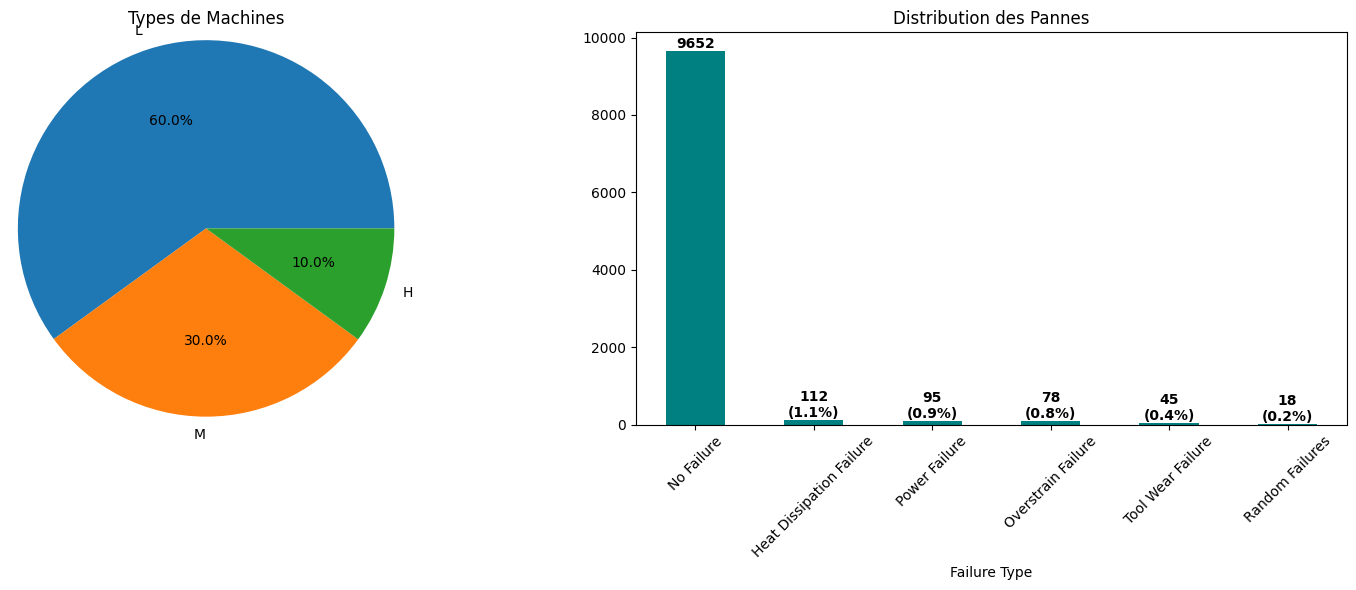

In [9]:
# On peut ajuster les ratios de largeur (ex: 1.2 pour le camembert, 1 pour les barres)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.2, 1]})

# 1. Camembert - Ajout de 'radius' pour augmenter la taille du cercle
dataset['Type'].value_counts().plot.pie(
    ax=axes[0], 
    autopct='%1.1f%%', 
    title="Types de Machines", 
    radius=1.2,        # Augmente la taille (par défaut c'est 1.0)
    labeldistance=1.1  # Éloigne un peu les labels pour ne pas qu'ils touchent le cercle
)
axes[0].set_ylabel('') # Nettoie le label vertical inutile

# 2. Bar Chart
counts = dataset['Failure Type'].value_counts()
counts.plot.bar(ax=axes[1], color='teal', title="Distribution des Pannes", rot=45)

# 3. Annotations
for i, (label, v) in enumerate(counts.items()):
    txt = f"{v}" if label == 'No Failure' else f"{v}\n({v/len(dataset):.1%})"
    axes[1].text(i, v, txt, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

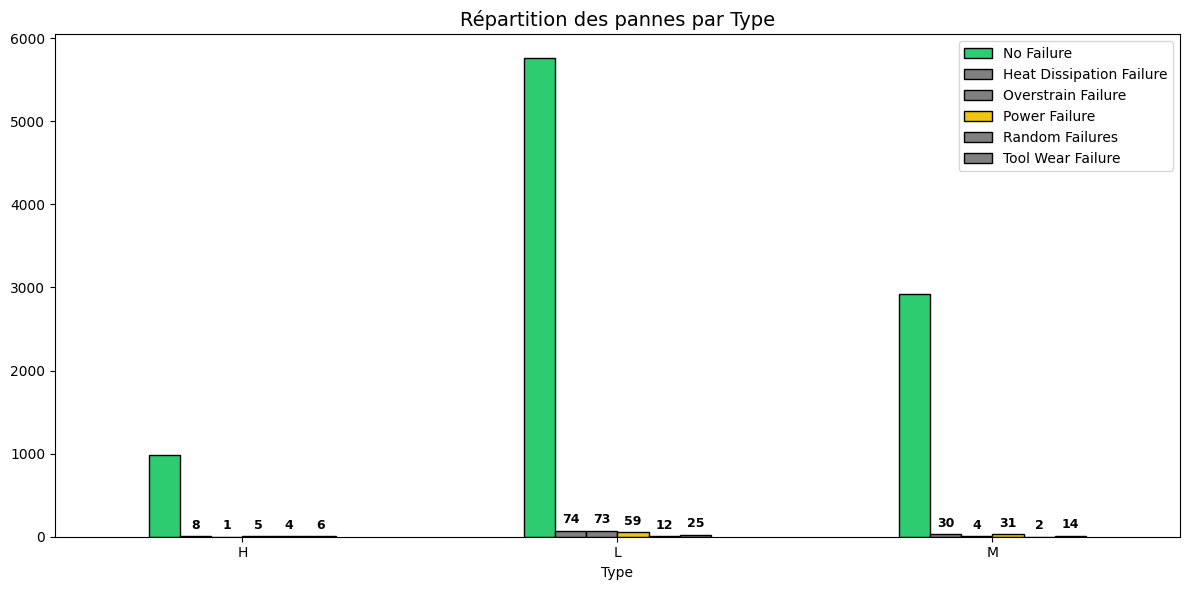

Failure Type,No Failure,Heat Dissipation Failure,Overstrain Failure,Power Failure,Random Failures,Tool Wear Failure
Type,,,,,,
H,979,8,1,5,4,6
L,5757,74,73,59,12,25
M,2916,30,4,31,2,14


In [10]:
# 1. Tableau croisé et réordonnancement (No Failure en premier)
ct = pd.crosstab(dataset['Type'], dataset['Failure Type'])
ct = ct[['No Failure'] + [c for c in ct.columns if c != 'No Failure']]

# 2. Plot direct avec palette de couleurs
colors = {'No Failure': '#2ecc71', 'Power Failure': '#f1c40f', 'Generator Failure': '#e74c3c', 'Gearbox Failure': '#e67e22', 'Component Failure': '#34495e'}
ax = ct.plot.bar(figsize=(12, 6), color=[colors.get(c, 'gray') for c in ct.columns], rot=0, edgecolor='black')

# 3. Labels automatiques (uniquement pour les pannes)
for i, container in enumerate(ax.containers):
    if ct.columns[i] != 'No Failure':
        ax.bar_label(container, padding=3, fontweight='bold', fontsize=9)

plt.title("Répartition des pannes par Type", fontsize=14)
plt.legend(bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

display(ct)

In [16]:
# Définir l'ordre logique
failure_mapping = {
    'No Failure': 0,
    'Heat Dissipation Failure': 1,
    'Power Failure': 2,
    'Overstrain Failure': 3,
    'Tool Wear Failure': 4,
    'Random Failures': 5
}

# Appliquer directement sur le dataset
dataset['Failure Type'] = dataset['Failure Type'].map(failure_mapping)

In [17]:
dataset

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0


NETTOYAGE 

In [18]:
# Correction de la faute de frappe : 'Target' et non 'Taget'
useless_cols = ['UDI', 'Product ID'] 

print("Dropping useless columns...")
# 'errors=ignore' permet de ne pas planter si les colonnes sont déjà supprimées
dataset = dataset.drop(columns=useless_cols, errors='ignore') 
print("...Done.")

print(dataset.head())

Dropping useless columns...
...Done.
  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Target  Failure Type  
0         42.8                0       0             0  
1         46.3                3       0             0  
2         49.4                5       0             0  
3         39.5                7       0             0  
4         40.0                9       0             0  


SEPARATION DES DATA

In [19]:
# Separate target variable Y from features X
target_name = 'Failure Type'

print("Separating labels from features...")
Y = dataset[target_name]
X = dataset.drop(target_name, axis = 1)
print("...Done.")
print(Y.head())
print()
print(X.head())
print()

Separating labels from features...
...Done.
0    0
1    0
2    0
3    0
4    0
Name: Failure Type, dtype: int64

  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Target  
0         42.8                0       0  
1         46.3                3       0  
2         49.4                5       0  
3         39.5                7       0  
4         40.0                9       0  



In [20]:
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, 
    test_size=0.20, 
    stratify=Y,
    random_state=0
)
print("...Done.")
print()

print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

print(f"\nTrain class distribution:")
print(Y_train.value_counts(normalize=True))

Dividing into train and test sets...
...Done.


Train set: (8000, 7)
Test set: (2000, 7)

Train class distribution:
Failure Type
0    0.96525
1    0.01125
2    0.00950
3    0.00775
4    0.00450
5    0.00175
Name: proportion, dtype: float64


PREPROCESSING

In [21]:
# Automatically detect names of numeric/categorical columns
numeric_features = []
categorical_features = []

for col, dtype in X_train.dtypes.items():
    if dtype in ['int64', 'float64']:
        numeric_features.append(col)
    else:
        # ❌ Exclu 'Target' si elle existe
        if col != 'Target':
            categorical_features.append(col)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print()

# Create pipeline for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

print("Numeric transformer created.")
print()

# Create pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False))
    ])

print("Categorical transformer created.")
print()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Preprocessor created successfully!")
print()

Numeric features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target']
Categorical features: ['Type']

Numeric transformer created.

Categorical transformer created.

Preprocessor created successfully!



In [22]:
# Preprocessing on train set
print("Performing preprocessing on train set...")
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(f"X_train shape after preprocessing: {X_train.shape}")
print(f"First 5 rows:\n{X_train[0:5,:]}")
print()

# Preprocessing on test set
print("Performing preprocessing on test set...")
X_test = preprocessor.transform(X_test)  # Don't fit again !!
print('...Done.')
print(f"X_test shape after preprocessing: {X_test.shape}")
print(f"First 5 rows:\n{X_test[0:5,:]}")
print()

Performing preprocessing on train set...
...Done.
X_train shape after preprocessing: (8000, 8)
First 5 rows:
[[ 0.39812601 -0.20650647  0.78271847 -1.17581363  1.26050903 -0.18689261
   0.          1.        ]
 [ 0.39812601  1.34237626 -0.91900965  1.02495822  0.71327313 -0.18689261
   1.          0.        ]
 [ 1.34611934  1.47706172 -0.51304183  0.75486349  0.90089687 -0.18689261
   1.          0.        ]
 [ 0.74738671  0.60160626  0.73266764 -0.88571188  0.96343811 -0.18689261
   1.          0.        ]
 [-0.84923363 -0.61056284 -0.65763311  0.74485999 -1.17859954 -0.18689261
   1.          0.        ]]

Performing preprocessing on test set...
...Done.
X_test shape after preprocessing: (2000, 8)
First 5 rows:
[[-8.99128013e-01 -6.10562840e-01 -1.41115526e-03 -3.45522431e-01
   4.00566904e-01 -1.86892613e-01  1.00000000e+00  0.00000000e+00]
 [-1.29828310e+00 -1.14930466e+00 -4.12940178e-01  2.04670531e-01
  -1.49130577e+00 -1.86892613e-01  1.00000000e+00  0.00000000e+00]
 [ 1.046753

BASELINE

In [23]:
baseline = LogisticRegression(class_weight='balanced')
baseline.fit(X_train, Y_train)

# Prédictions
y_pred = baseline.predict(X_test)

# La vérité est ici
print(confusion_matrix(Y_test, y_pred))
print(classification_report(Y_test, y_pred))

[[1387    1    2    1    1  538]
 [   0   21    0    1    0    0]
 [   0    1   18    0    0    0]
 [   0    0    0   16    0    0]
 [   0    0    0    2    7    0]
 [   1    0    0    0    0    3]]
              precision    recall  f1-score   support

           0       1.00      0.72      0.84      1930
           1       0.91      0.95      0.93        22
           2       0.90      0.95      0.92        19
           3       0.80      1.00      0.89        16
           4       0.88      0.78      0.82         9
           5       0.01      0.75      0.01         4

    accuracy                           0.73      2000
   macro avg       0.75      0.86      0.74      2000
weighted avg       0.99      0.73      0.84      2000



c:\Users\Juju\anaconda3\envs\projet-final\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SELECTION DU MODEL

In [24]:
# Train model
model = LogisticRegression(class_weight='balanced', max_iter=100)

print("Training model...")
model.fit(X_train, Y_train) # Training is always done on train set !!
print("...Done.")

Training model...
...Done.


c:\Users\Juju\anaconda3\envs\projet-final\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


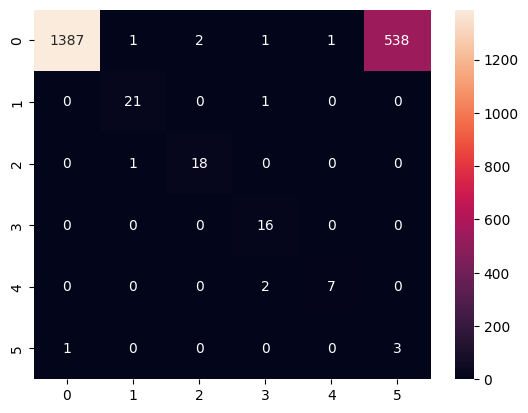

In [25]:
Y_train_pred = baseline.predict(X_train)
Y_test_pred = baseline.predict(X_test)

cm = confusion_matrix(Y_test, Y_test_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [44]:
# ========== RANDOMFOREST MODEL ==========
print("\nTraining RF (Random Forest)...")
rf = RandomForestClassifier(
    n_estimators=50,      # Plus d'arbres
    class_weight='balanced',
    max_depth=10,          # Entre 6 et 12
    min_samples_split=2,   # Moins restrictif
    min_samples_leaf=2,    # Moins restrictif
    random_state=0
)

rf.fit(X_train, Y_train)
print("...Done.")

# ========== rf EVALUATION ==========
Y_train_pred = rf.predict(X_train)
Y_test_pred = rf.predict(X_test)

print("\n" + "="*60)
print("rf RESULTS")
print("="*60)

# F1-Score (correct metric for challenge!)
f1_train = f1_score(Y_train, Y_train_pred, average='macro')
f1_test = f1_score(Y_test, Y_test_pred, average='macro')

print(f"F1-Score (Macro) Train: {f1_train:.4f}")
print(f"F1-Score (Macro) Test: {f1_test:.4f}")


Training RF (Random Forest)...
...Done.

rf RESULTS
F1-Score (Macro) Train: 0.9918
F1-Score (Macro) Test: 0.7446


In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer

# 1. Définition de la grille d'hyperparamètres
# On teste autour de tes valeurs actuelles pour challenger tes choix
param_grid = {
    'n_estimators': [30, 50],
    'max_depth': [5, 10],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# 2. Configuration du scorer (F1 Macro)
f1_macro_scorer = make_scorer(f1_score, average='macro')

# 3. Initialisation du Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=0, n_jobs=-1),
    param_grid=param_grid,
    scoring=f1_macro_scorer,
    cv=5,          # Stratified 5-fold par défaut pour la classification
    verbose=1,
    n_jobs=-1
)

print("\nLancement du Grid Search...")
grid_search.fit(X_train, Y_train)

# 4. Extraction des meilleurs résultats
best_rf = grid_search.best_estimator_
print(f"\nMeilleurs paramètres trouvés : {grid_search.best_params_}")
print(f"Meilleur score F1 (CV) : {grid_search.best_score_:.4f}")

# 5. Évaluation finale
Y_test_pred = best_rf.predict(X_test)
f1_test = f1_score(Y_test, Y_test_pred, average='macro')

print("\n" + "="*60)
print(f"RÉSULTAT OPTIMISÉ - F1-Score (macro) Test: {f1_test:.4f}")
print("="*60)


Lancement du Grid Search...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Meilleurs paramètres trouvés : {'class_weight': 'balanced_subsample', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
Meilleur score F1 (CV) : 0.7988

RÉSULTAT OPTIMISÉ - F1-Score (macro) Test: 0.7401


PREDICTION

In [18]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = rf.predict(X_train)
print("...Done.")
print(Y_train_pred[0:5])
print()

Predictions on training set...
...Done.
[0 0 0 0 0]



In [19]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = rf.predict(X_test)
print("...Done.")
print(Y_test_pred[0:5])
print()

Predictions on test set...
...Done.
[0 0 0 0 0]



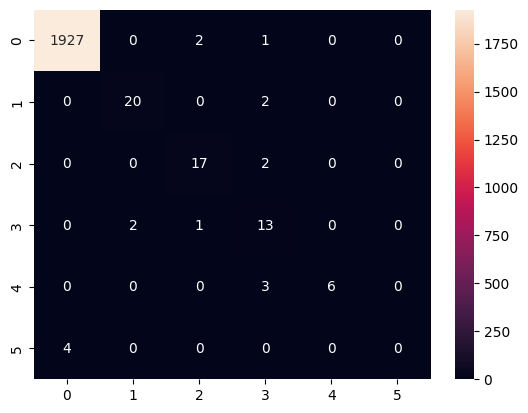

In [45]:
Y_train_pred = rf.predict(X_train)
Y_test_pred = rf.predict(X_test)

cm = confusion_matrix(Y_test, Y_test_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

SCORING DU MODEL

In [46]:
# Print scores
print("Accuracy on training set : ", accuracy_score(Y_train, Y_train_pred))
print("Accuracy on test set : ", accuracy_score(Y_test, Y_test_pred))

print("F1 Train (Macro):", f1_score(Y_train, Y_train_pred, average='macro'))
print("F1 Test (Macro):", f1_score(Y_test, Y_test_pred, average='macro'))

Accuracy on training set :  0.99925
Accuracy on test set :  0.9915
F1 Train (Macro): 0.9937065588306454
F1 Test (Macro): 0.7136292469625802
